# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [3]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [4]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Double check some datatypes, and for nulls and duplicates:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [9]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [10]:
df.Segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [11]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [12]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [13]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [14]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [15]:
query2 = """ SELECT
    c.customer_id,
    c.customer_name,
    SUM(oi.quantity * oi.profit * (1 - oi.discount)) AS total_sales
FROM customers AS c
JOIN orders AS o ON c.customer_id = o.customer_id
JOIN order_details AS oi ON o.order_id = oi.order_id
GROUP BY c.customer_id
ORDER BY total_sales DESC
LIMIT 10;
"""
result2 = pd.read_sql(query2, conn)
result2

,customer_id,customer_name,total_sales
0,AB-10105,Adrian Barton,600953.96628
1,SC-20095,Sanjit Chand,235072.20186
2,TC-20980,Tamara Chand,219888.89890
3,DR-12940,Daniel Raglin,218611.96896
4,RB-19360,Raymond Buch,168922.64646
5,HM-14860,Harry Marie,165700.80584
6,SE-20110,Sanjit Engle,165276.03994
7,PK-19075,Pete Kriz,116256.24432
8,HL-15040,Hunter Lopez,110425.83696
9,BM-11650,Brian Moss,109117.94465


### Which product categories and subcategories are the most profitable overall?

In [16]:
query3 = """
SELECT
    Category AS category_name,
    SubCategory AS subcategory_name,
    SUM(product_id) AS product_id
FROM products
GROUP BY
    Category,
    SubCategory
ORDER BY
    product_id DESC
LIMIT 10;
"""

result3 = pd.read_sql(query3, conn)
result3

,category_name,subcategory_name,product_id
0,Furniture,Bookcases,0.0
1,Furniture,Chairs,0.0
2,Furniture,Furnishings,0.0
3,Furniture,Tables,0.0
4,Office Supplies,Appliances,0.0
5,Office Supplies,Art,0.0
6,Office Supplies,Binders,0.0
7,Office Supplies,Envelopes,0.0
8,Office Supplies,Fasteners,0.0
9,Office Supplies,Labels,0.0


### What is the average discount given per category?

In [19]:
query4 = """
SELECT
    product_id,
    AVG(Discount) AS avg_discount
FROM Order_Details
GROUP BY
    product_id
ORDER BY
    avg_discount DESC;
"""

result4 = pd.read_sql(query4, conn)
result4

,product_id,avg_discount
0,OFF-AP-10002203,0.800000
1,OFF-BI-10003166,0.728571
2,OFF-BI-10000778,0.725000
3,TEC-MA-10004521,0.700000
4,TEC-MA-10004086,0.700000
...,...,...
1857,FUR-FU-10000672,0.000000
1858,FUR-FU-10000448,0.000000
1859,FUR-FU-10000397,0.000000
1860,FUR-BO-10003404,0.000000


### Which states or regions contribute the most to total sales?

In [32]:
query5 = """
SELECT
    c.State AS state,
    SUM(od.Sales) AS total_sales
FROM customers c
JOIN orders o
    ON o.Customer_ID = c.Customer_ID
JOIN Order_Details od
    ON o.Order_ID = od.Order_ID
GROUP BY
   Region
ORDER BY
    total_sales DESC;
"""

result5 = pd.read_sql(query5, conn)
result5

,state,total_sales
0,California,5.306522e+06
1,Pennsylvania,4.522990e+06
2,Texas,3.853692e+06
3,Kentucky,2.706438e+06


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [34]:
query6 = """
SELECT
    o.Order_ID,
    o.Order_Date,
    o.Ship_Date,
    o.Customer_ID,
    o.State,
    o.Region
FROM Orders o
WHERE DATE(o.Ship_Date) > DATE(o.Order_Date, '+3 days')
ORDER BY o.Ship_Date;
"""

result6 = pd.read_sql(query5, conn)
result6

,state,total_sales
0,California,5.306522e+06
1,Pennsylvania,4.522990e+06
2,Texas,3.853692e+06
3,Kentucky,2.706438e+06


### Which month or year had the highest total sales?

In [35]:
query7 = """
SELECT
    STRFTIME('%Y', o.Order_Date) AS year,
    SUM(od.Sales) AS total_sales
FROM Orders o
JOIN Order_Details od
    ON o.Order_ID = od.Order_ID
GROUP BY
    STRFTIME('%Y', o.Order_Date)
ORDER BY
    total_sales DESC;
"""

result7 = pd.read_sql(query7, conn)
result7

,year,total_sales
0,2014,733947.0232
1,2013,608473.8300
2,2011,484247.4981
3,2012,470532.5090


### What are the most frequently ordered products?

In [38]:
query8 = """
SELECT
    product_id,
    SUM(Quantity) AS total_quantity_ordered
FROM order_details
GROUP BY
    Product_id
ORDER BY
    total_quantity_ordered DESC;
"""

result8 = pd.read_sql(query8, conn)
result8

,product_id,total_quantity_ordered
0,TEC-AC-10003832,75
1,OFF-PA-10001970,70
2,OFF-BI-10001524,67
3,OFF-BI-10002026,64
4,FUR-CH-10002647,64
...,...,...
1857,TEC-MA-10003493,1
1858,OFF-PA-10000048,1
1859,OFF-AR-10002704,1
1860,FUR-CH-10002317,1


### Which customers placed more than 5 orders total?

In [39]:
query9 = """
SELECT
    c.Customer_ID,
    c.Customer_Name,
    COUNT(o.Order_ID) AS total_orders
FROM Customers c
JOIN Orders o
    ON c.Customer_ID = o.Customer_ID
GROUP BY
    c.Customer_ID,
    c.Customer_Name
HAVING
    COUNT(o.Order_ID) > 5
ORDER BY
    total_orders DESC;
"""

result9 = pd.read_sql(query9, conn)
result9

,customer_id,customer_name,total_orders
0,EP-13915,Emily Phan,289
1,EA-14035,Erin Ashbrook,169
2,JE-15745,Joel Eaton,169
3,SH-19975,Sally Hughsby,169
4,ZC-21910,Zuschuss Carroll,169
...,...,...,...
742,SS-20515,Shirley Schmidt,9
743,SW-20350,Sean Wendt,9
744,TM-21490,Tony Molinari,9
745,TT-21265,Tim Taslimi,9


### What’s the profit margin (profit ÷ sales) by category or segment?

In [41]:
query10 = """
SELECT
    Order_id,
    SUM(Profit) AS total_profit,
    SUM(Sales) AS total_sales,
    SUM(Profit) * 1.0 / SUM(Sales) AS profit_margin
FROM Order_Details
GROUP BY
    product_id
ORDER BY
    profit_margin DESC;
"""

result10 = pd.read_sql(query10, conn)
result10

,order_id,total_profit,total_sales,profit_margin
0,CA-2011-164973,1995.9900,3991.980,0.500000
1,CA-2013-134775,36.4000,72.800,0.500000
2,CA-2013-112942,171.2900,342.580,0.500000
3,CA-2011-131926,111.7200,223.440,0.500000
4,CA-2012-165624,122.3500,244.700,0.500000
...,...,...,...,...
1857,US-2013-157490,-938.2800,703.710,-1.333333
1858,CA-2013-159023,-251.9874,179.991,-1.400000
1859,CA-2014-155824,-325.6332,170.744,-1.907143
1860,CA-2013-157707,-190.8522,90.882,-2.100000


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

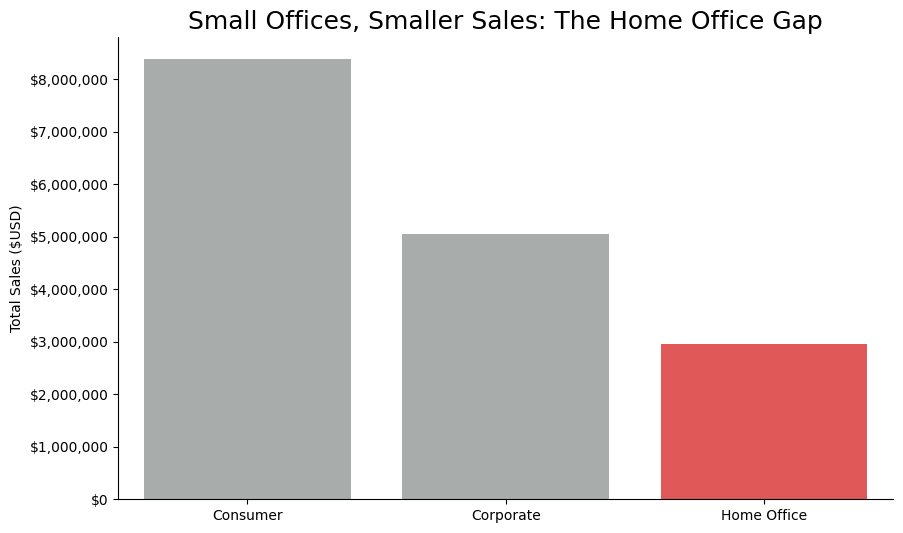

In [42]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


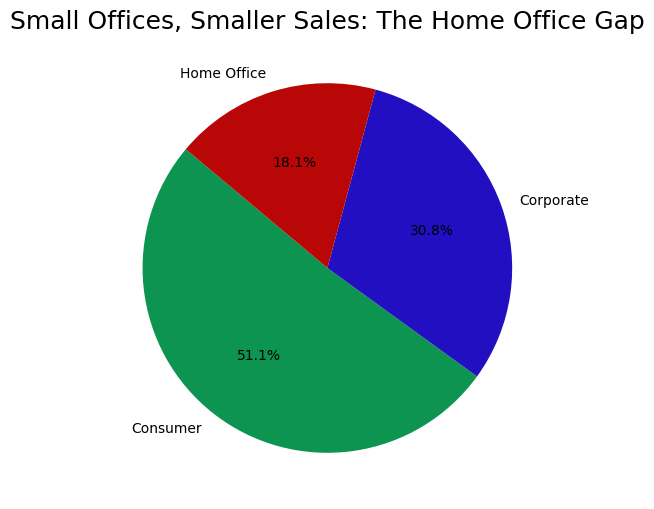

In [47]:
plt.figure(figsize=(10,6))
colors = ["#0c9450", "#210FC1", "#B90606"]

plt.pie(
    result1['total_sales'],
    labels=result1['customer_category'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Small Offices, Smaller Sales: The Home Office Gap', fontsize=18)

plt.show()

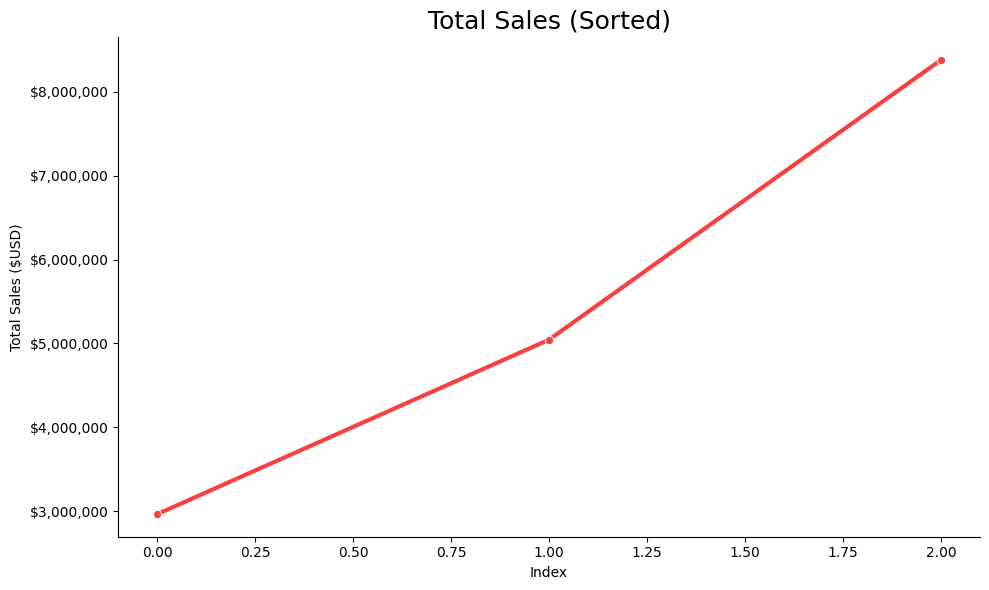

In [ ]:
plt.figure(figsize=(10,6))

result1_sorted = result1.sort_values("total_sales").reset_index(drop=True)

sns.lineplot(
    data=result1_sorted,
    x=result1_sorted.index,
    y='total_sales',
    color="#f74141",
    marker='o',
    linewidth=3
)

plt.title('Total Sales (Sorted)', fontsize=18)
plt.xlabel("Index")
plt.ylabel("Total Sales ($USD)")

plt.ticklabel_format(style='plain', axis='y')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# visualization four code here



In [ ]:
# visualization four code here